In [1]:
import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")
import lal

import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
import functions
import bilby, time
import seaborn as sns
import pandas as pd
from pprint import pprint

In [2]:
sns.set_theme(context="talk", palette="husl", style="whitegrid")
palette = sns.color_palette("husl")

In [3]:
# ---------------------------
# Priors
# ---------------------------
priors = bilby.core.prior.PriorDict()
priors['mass_1'] = bilby.core.prior.analytical.PowerLaw(minimum=5, maximum=50, alpha=-2.3,
                                                        name='mass_1')
priors['a_1'] = bilby.core.prior.Uniform(name='a_1', minimum=0, maximum=0.1)
priors['tilt_1'] = bilby.core.prior.analytical.Sine(name='tilt_1', minimum=0, maximum=np.pi)
priors['tilt_2'] = bilby.core.prior.analytical.Sine(name='tilt_2', minimum=0, maximum=np.pi)
priors['phi_12'] = bilby.core.prior.Uniform(name='phi_12', minimum=0,
                                            maximum=2 * np.pi, boundary='periodic')
priors['phi_jl'] = bilby.core.prior.Uniform(name='phi_jl', minimum=0,
                                            maximum=2 * np.pi, boundary='periodic')
priors['phase'] = bilby.core.prior.Uniform(name='phase', minimum=0,
                                           maximum=2 * np.pi, boundary='periodic')
priors['theta_jn'] = bilby.core.prior.analytical.Sine(name='theta_jn')
print("Priors used for 1G population:")
pprint(priors)

Priors used for 1G population:
{'a_1': Uniform(minimum=0, maximum=0.1, name='a_1', latex_label='$a_1$', unit=None, boundary=None),
 'mass_1': PowerLaw(alpha=-2.3, minimum=5, maximum=50, name='mass_1', latex_label='$m_1$', unit=None, boundary=None),
 'phase': Uniform(minimum=0, maximum=6.283185307179586, name='phase', latex_label='$\\phi$', unit=None, boundary='periodic'),
 'phi_12': Uniform(minimum=0, maximum=6.283185307179586, name='phi_12', latex_label='$\\Delta\\phi$', unit=None, boundary='periodic'),
 'phi_jl': Uniform(minimum=0, maximum=6.283185307179586, name='phi_jl', latex_label='$\\phi_{JL}$', unit=None, boundary='periodic'),
 'theta_jn': Sine(minimum=0, maximum=3.141592653589793, name='theta_jn', latex_label='$\\theta_{JN}$', unit=None, boundary=None),
 'tilt_1': Sine(minimum=0, maximum=3.141592653589793, name='tilt_1', latex_label='$\\theta_1$', unit=None, boundary=None),
 'tilt_2': Sine(minimum=0, maximum=3.141592653589793, name='tilt_2', latex_label='$\\theta_2$', unit=Non

## By mergers

In [4]:
N_initial = 400
N_branches = 100

start_time = time.time()

mergers = {}
for i in tqdm(range(N_branches)):
    mergers[i] = functions.create_ngng_chain_mergers(priors, N_initial)

end_time = time.time()
elapsed_time = end_time - start_time
print(f"Elapsed time: {elapsed_time:.3f} seconds")

100%|██████████| 100/100 [06:14<00:00,  3.75s/it]

Elapsed time: 374.647 seconds


In [5]:
# get all unique Ng values across branches
all_Ng = sorted(set(np.concatenate([mergers[i].index + 1 for i in mergers])))

# for each Ng, gather final mass values from all branches
m_f_by_Ng = {Ng: [] for Ng in all_Ng}

# for each branch
for i in mergers:
    # for each Ng and corresponding final mass
    for Ng, mf in zip((mergers[i].index + 1), mergers[i]["m_f"]):
        # append it to the list
        m_f_by_Ng[Ng].append(mf)

lower, upper, median = [], [], []
for Ng in all_Ng:
    mfs = np.array(m_f_by_Ng[Ng])
    lower.append(np.percentile(mfs, 5))
    upper.append(np.percentile(mfs, 95))
    median.append(np.median(mfs))

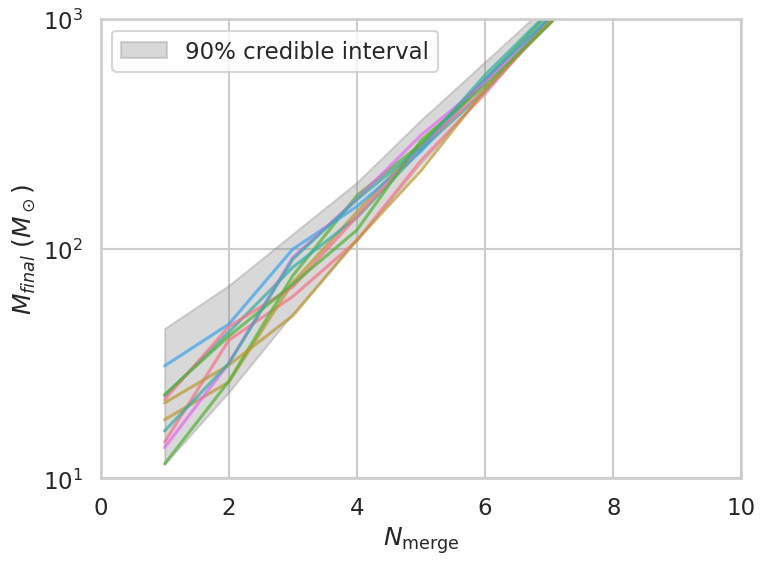

In [6]:
# pick 10 random branches
sample_idxs = np.random.choice(list(mergers.keys()), size=10, replace=False)

plt.figure(figsize=(8,6))

for i in sample_idxs:
    plt.plot(mergers[i].index + 1, mergers[i]["m_f"], alpha=0.7)

plt.fill_between(all_Ng, lower, upper, color='gray', alpha=0.3, label='90% credible interval')

plt.yscale('log')
plt.ylabel(r'$M_{final}$ ($M_\odot$)')
plt.ylim(1e1,1e3)
plt.xlim(0,10)
plt.xlabel(r"$N_{\text{merge}}$")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()